# Ovrlpy applied to vizgen receptor data map



In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import ovrlpy
import pandas as pd

In [2]:
import sys

import matplotlib

sys.path.append("..")

from utils import CM, FONT, save_kwargs

matplotlib.rc("font", **FONT)

In [3]:
n_slice = 2

coordinate_path = "./detected_transcripts.parquet"
signature_file = (
    "/dh-projects/ag-ishaque/raw_data/Xenium-benchmark/scRNAseq/trimmed_means.csv"
)

In [4]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True, parents=True)

In [5]:
coordinate_df = ovrlpy.io.read_MERSCOPE(coordinate_path, additional_columns=["cell_id"])

print(
    f"Number of cells: {coordinate_df['cell_id'].n_unique():,}",
    f"Number of genes: {coordinate_df['gene'].n_unique():,}",
    f"Number of molecules: {coordinate_df.shape[0]:,}",
    sep="\n",
)

Number of cells: 83,506
Number of genes: 483
Number of molecules: 48,574,461


In [6]:
brain = ovrlpy.Ovrlp(coordinate_df, n_components=30, n_workers=16, random_state=42)
brain.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 50370 pseudocells
sampling expression:


100%|██████████| 56/56 [00:58<00:00,  1.05s/it]


Modeling 30 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 320/320 [07:24<00:00,  1.39s/it]


In [7]:
signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [8]:
signatures = pd.read_csv(signature_file, index_col=0).T.loc[
    :, lambda df: df.columns.isin(brain.genes)
]

signatures = signatures.groupby(
    lambda x: x.split("_")[1].split(" ")[0].split("-")[0]
).mean()

signatures.index = signatures.index.str.replace("/", "-")
signatures.index.name = "celltype"
signatures.columns.name = "gene"

In [9]:
brain.fit_signatures(signatures)

In [10]:
import pickle

with open("merscope_brain.pickle", "wb") as file:
    pickle.dump(brain, file)

In [5]:
import pickle

with open("merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

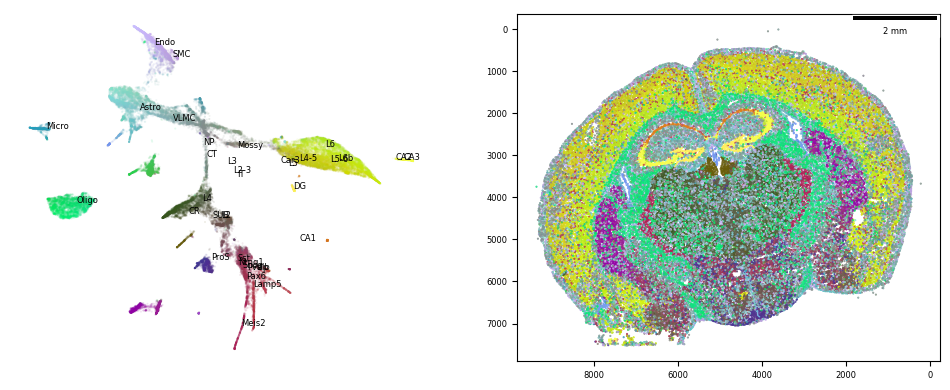

In [6]:
fig = ovrlpy.plot_pseudocells(brain)

fig.axes[1].invert_yaxis()
fig.axes[1].invert_xaxis()

fig.savefig(out_dir / "receptor-fit.svg", dpi=600)

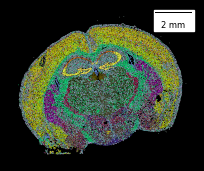

In [10]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(9 * CM, 5 * CM))
    _ = ovrlpy.plot_tissue(brain, ax=ax, **scatter_kwargs)
    ax.set_axis_off()
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.collections[0].set_rasterized(True)
    fig.savefig(out_dir / "localmaxima.svg", **save_kwargs)

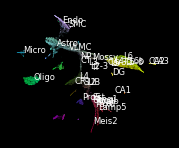

In [11]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(5 * CM, 5 * CM))
    _ = ovrlpy.plot_umap(brain, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig(out_dir / "umap.svg", **save_kwargs)
    fig.savefig(out_dir / "umap.pdf", **save_kwargs)